# 任务四：过拟合与正则化实践

这个任务的目标和前面三个任务不太一样。

前面几个任务主要是在比较“不同设置会不会让模型更强”，
而任务四是要我们先故意制造一个问题，再想办法缓解这个问题。

这里要故意制造的问题就是：**过拟合**。

过拟合可以先简单理解成：

- 模型在训练集上学得越来越好
- 但是在验证集上并没有同步变好
- 甚至可能出现“训练集准确率继续上升，但验证集准确率开始下降”的情况

这说明模型更像是在“记住训练数据”，
而不是学到了更普遍、更稳定的规律。

这次实验我们会做两组对比：

1. 深层网络，不加正则化
2. 深层网络，在每个隐藏层后加入 `Dropout(p=0.5)`

我们会故意让模型更容易过拟合，方法有两个：

- 把网络加深：`784 -> 512 -> 256 -> 128 -> 10`
- 把训练数据减少：只使用原训练池中的 10%

训练轮数也会增加到 `50` 轮，这样更容易观察到后期的过拟合现象。


## 第 1 步：导入库并设置实验参数

这一格主要做四件事：

1. 导入需要的库
2. 设置随机种子
3. 设置一些全局超参数
4. 定义实验分组

这里有几个参数需要重点理解：

- `NUM_EPOCHS = 50`
  训练轮数比前面任务更多，是为了更容易观察到后期是否出现过拟合。

- `REDUCED_TRAIN_RATIO = 0.1`
  表示只用训练池中的 10% 样本做真正训练。
  训练数据变少后，模型更容易把训练集“记住”。

- `DROPOUT_P = 0.5`
  这是 Dropout 的丢弃率。
  可以简单理解成：训练时随机让一半神经元暂时不工作。
  这样可以减少模型过度依赖某些局部特征，从而缓解过拟合。

- `EXPERIMENTS`
  用一个字典统一管理实验分组，后面可以直接循环训练。


In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random
import time
from pathlib import Path
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
VALID_RATIO = 0.1
REDUCED_TRAIN_RATIO = 0.1
DROPOUT_P = 0.5

# 两组实验：不加正则化 / 加入 Dropout
EXPERIMENTS = {
    "No_Regularization": {"use_dropout": False},
    "Dropout_p0.5": {"use_dropout": True},
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 第 2 步：准备数据，并故意缩小训练集

这一格是整个任务四里非常关键的一格。

因为“过拟合”不是凭空出现的，
通常是因为模型能力太强、训练数据太少，或者训练时间太长。

这次我们故意做的事情就是：

- 先像前面一样，从完整训练集中划出验证集
- 再从剩下的训练池中，只抽取 10% 做真正训练

这里为什么不是直接从 60000 张里面随便拿 10%？

因为我们想保留一个稳定的验证集用于观察泛化效果。
所以更合理的流程是：

1. 先从完整训练集划出验证集
2. 再从训练池中抽出 10% 作为训练子集

这样训练集会明显变小，而验证集仍然相对稳定，
更有利于观察“训练越来越好，但验证不一定同步变好”的现象。


### 这一格几个参数的含义

- `transform = transforms.ToTensor()`
  把图片转成张量，并把像素值缩放到 `[0, 1]`。

- `valid_size`
  验证集样本数。

- `train_pool`
  从完整训练集划出验证集后，剩下的大训练池。

- `reduced_train_size`
  真正拿来训练的小子集大小。

- `random_split(...)`
  随机划分数据集。

- `generator=torch.Generator().manual_seed(...)`
  固定划分的随机过程，让每次实验更容易复现。


In [2]:
def build_dataloaders(data_root: Path):
    transform = transforms.ToTensor()

    train_full = datasets.FashionMNIST(
        root=str(data_root),
        train=True,
        transform=transform,
        download=False,
    )
    test_dataset = datasets.FashionMNIST(
        root=str(data_root),
        train=False,
        transform=transform,
        download=False,
    )

    valid_size = int(len(train_full) * VALID_RATIO)
    train_pool_size = len(train_full) - valid_size

    split_generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_pool, valid_dataset = random_split(
        train_full,
        [train_pool_size, valid_size],
        generator=split_generator,
    )

    reduced_train_size = max(1, int(len(train_pool) * REDUCED_TRAIN_RATIO))
    remaining_size = len(train_pool) - reduced_train_size

    subset_generator = torch.Generator().manual_seed(RANDOM_SEED)
    reduced_train_dataset, _ = random_split(
        train_pool,
        [reduced_train_size, remaining_size],
        generator=subset_generator,
    )

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }

    train_loader = DataLoader(reduced_train_dataset, shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
    return train_loader, valid_loader, test_loader, reduced_train_size, len(valid_dataset)


set_seed(RANDOM_SEED)
device = get_device()
data_root = Path.cwd() / "fashion_mnist"

train_loader, valid_loader, test_loader, train_subset_size, valid_size = build_dataloaders(data_root)

print("当前设备：", device)
print("数据目录：", data_root)
print("训练子集样本数：", train_subset_size)
print("验证集样本数：", valid_size)
print("实验分组：", list(EXPERIMENTS.keys()))
print(f"训练集批次数：{len(train_loader)}")
print(f"验证集批次数：{len(valid_loader)}")
print(f"测试集批次数：{len(test_loader)}")


当前设备： cuda
数据目录： C:\Users\qintian\Desktop\人工智能\实验三_发送版\fashion_mnist
训练子集样本数： 5400
验证集样本数： 6000
实验分组： ['No_Regularization', 'Dropout_p0.5']
训练集批次数：85
验证集批次数：94
测试集批次数：157


## 第 3 步：定义更深的网络结构

前面任务一到任务三用的都是比较基础的单隐藏层结构。

这次为了更容易制造过拟合，我们故意把网络加深到：

`784 -> 512 -> 256 -> 128 -> 10`

也就是说：

- 输入层还是 784 维
- 第一隐藏层 512 个神经元
- 第二隐藏层 256 个神经元
- 第三隐藏层 128 个神经元
- 输出层 10 类

所有隐藏层都用 `ReLU`。

同时，这个类里还增加了 `use_dropout` 参数。

这个参数非常重要：

- `use_dropout=False`
  表示构建“不加正则化”的深层网络

- `use_dropout=True`
  表示在每个隐藏层后都插入 `Dropout(p=0.5)`

这样写的好处是：
我们可以用同一个模型类，方便地得到两组实验模型，
保证除了 Dropout 之外，其余结构都一致。


### `Dropout(p=0.5)` 到底是什么意思

这一点很多初学者第一次看会比较抽象。

你可以先把它理解成：

在训练阶段，每次前向传播时，都会随机让一部分神经元“暂时下线”。

当 `p=0.5` 时，可以粗略理解成：

- 当前这一轮里，大约有一半神经元会被临时屏蔽

这样做的作用是：

- 防止模型过度依赖某几个固定神经元
- 让网络学到更分散、更稳健的表示
- 从而减少过拟合

注意：

- 训练时 Dropout 生效
- 验证和测试时 Dropout 会自动关闭

所以它不会让测试时“真的少一半神经元”，
它只是训练阶段的一种正则化手段。


In [3]:
class DeepMLP(nn.Module):
    def __init__(self, use_dropout: bool = False, dropout_p: float = DROPOUT_P) -> None:
        super().__init__()

        layers = [
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
        ]
        if use_dropout:
            layers.append(nn.Dropout(p=dropout_p))

        layers.extend(
            [
                nn.Linear(512, 256),
                nn.ReLU(),
            ]
        )
        if use_dropout:
            layers.append(nn.Dropout(p=dropout_p))

        layers.extend(
            [
                nn.Linear(256, 128),
                nn.ReLU(),
            ]
        )
        if use_dropout:
            layers.append(nn.Dropout(p=dropout_p))

        layers.append(nn.Linear(128, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

print("无正则化模型：")
print(DeepMLP(use_dropout=False))

print("\n加入 Dropout 的模型：")
print(DeepMLP(use_dropout=True))


无正则化模型：
DeepMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

加入 Dropout 的模型：
DeepMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.5, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 第 4 步：定义训练、验证和测试函数

这一部分和前面任务的训练框架基本一致，
但这次多记录了一个很关键的指标：`accuracy_gap`。

这里的 `accuracy_gap` 定义为：

`训练准确率 - 验证准确率`

它的意义是：

- 如果 gap 很小，说明训练集和验证集表现比较接近
- 如果 gap 越来越大，通常说明模型越来越偏向“只会训练集”

所以在任务四里，这个 gap 是观察过拟合的重要依据。

这次训练函数 `train_model(...)` 里最需要你注意的点有：

- `experiment_name`
  当前实验组名称，比如“不加正则化”或“加入 Dropout”

- `use_dropout`
  决定构建哪种网络

- `best_state_dict`
  记录验证集表现最好时的参数

- `history`
  把每轮的损失、准确率、gap 和耗时都存下来


In [4]:
def run_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> tuple[float, float]:
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(
    experiment_name: str,
    use_dropout: bool,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    set_seed(RANDOM_SEED)

    model = DeepMLP(use_dropout=use_dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_valid_acc = 0.0

    print(f"\n========== 开始训练：{experiment_name} ==========")

    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()

        train_loss, train_acc = run_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )
        valid_loss, valid_acc = run_one_epoch(
            model=model,
            dataloader=valid_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
        )

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_state_dict = copy.deepcopy(model.state_dict())

        epoch_seconds = time.time() - start_time
        history.append(
            {
                "experiment": experiment_name,
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "valid_loss": valid_loss,
                "valid_accuracy": valid_acc,
                "accuracy_gap": train_acc - valid_acc,
                "seconds": epoch_seconds,
            }
        )

        print(
            f"{experiment_name} | Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f} | "
            f"gap={train_acc - valid_acc:.4f}"
        )

    model.load_state_dict(best_state_dict)
    return model, pd.DataFrame(history)


def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    return run_one_epoch(
        model=model,
        dataloader=dataloader,
        criterion=criterion,
        optimizer=None,
        device=device,
    )


## 第 5 步：正式运行两组实验

这里就是任务四的主实验部分。

我们会按顺序做两件事：

1. 训练不加正则化的深层网络
2. 训练加入 Dropout 的深层网络

为了让比较尽量公平，这两组实验保持以下条件一致：

- 相同的数据划分
- 相同的训练子集
- 相同的损失函数
- 相同的优化器（Adam）
- 相同的学习率
- 相同的训练轮数

唯一变化的是：

- 是否加入 Dropout

这样最后看到的差异，就更能说明是正则化造成的。


In [5]:
criterion = nn.CrossEntropyLoss()

histories = {}
test_results = {}

for experiment_name, config in EXPERIMENTS.items():
    model, history_df = train_model(
        experiment_name=experiment_name,
        use_dropout=config["use_dropout"],
        train_loader=train_loader,
        valid_loader=valid_loader,
        criterion=criterion,
        device=device,
    )
    histories[experiment_name] = history_df
    test_results[experiment_name] = evaluate_model(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device,
    )



========== 开始训练：No_Regularization ==========
No_Regularization | Epoch 01/50 | train_loss=1.0096, train_acc=0.6311 | valid_loss=0.6509, valid_acc=0.7612 | gap=-0.1301
No_Regularization | Epoch 02/50 | train_loss=0.5879, train_acc=0.7828 | valid_loss=0.5786, valid_acc=0.8020 | gap=-0.0192
No_Regularization | Epoch 03/50 | train_loss=0.4925, train_acc=0.8259 | valid_loss=0.5450, valid_acc=0.8107 | gap=0.0153
No_Regularization | Epoch 04/50 | train_loss=0.4408, train_acc=0.8413 | valid_loss=0.5360, valid_acc=0.8215 | gap=0.0198
No_Regularization | Epoch 05/50 | train_loss=0.4130, train_acc=0.8524 | valid_loss=0.4929, valid_acc=0.8265 | gap=0.0259
No_Regularization | Epoch 06/50 | train_loss=0.3711, train_acc=0.8646 | valid_loss=0.5256, valid_acc=0.8135 | gap=0.0511
No_Regularization | Epoch 07/50 | train_loss=0.3788, train_acc=0.8591 | valid_loss=0.4568, valid_acc=0.8360 | gap=0.0231
No_Regularization | Epoch 08/50 | train_loss=0.3212, train_acc=0.8802 | valid_loss=0.4894, valid_acc=0.83

## 第 6 步：整理结果汇总表

这一格会把两组实验中最关键的信息整理成一个表格。

表里几列最值得你关注：

- `Best Valid Accuracy`
  验证集上达到的最高准确率

- `Epoch of Best Valid Accuracy`
  验证集最高准确率出现在第几轮

- `Final Train Accuracy`
  最后一轮训练准确率

- `Final Valid Accuracy`
  最后一轮验证准确率

- `Final Accuracy Gap`
  最后一轮训练准确率和验证准确率之间的差

- `Test Accuracy`
  在测试集上的最终效果

在任务四里，不一定是“训练准确率越高越好”，
更关键的是验证集表现和训练/验证之间的间隙。

如果某个模型训练集很高，但验证集一般，而且 gap 很大，
往往就说明过拟合更明显。


In [6]:
def summarize_results(
    histories: dict[str, pd.DataFrame],
    test_results: dict[str, tuple[float, float]],
) -> pd.DataFrame:
    summary_rows = []

    for experiment_name, history_df in histories.items():
        best_row = history_df.loc[history_df["valid_accuracy"].idxmax()]
        test_loss, test_acc = test_results[experiment_name]

        summary_rows.append(
            {
                "Experiment": experiment_name,
                "Best Valid Accuracy": best_row["valid_accuracy"],
                "Epoch of Best Valid Accuracy": int(best_row["epoch"]),
                "Final Train Accuracy": history_df.iloc[-1]["train_accuracy"],
                "Final Valid Accuracy": history_df.iloc[-1]["valid_accuracy"],
                "Final Accuracy Gap": history_df.iloc[-1]["accuracy_gap"],
                "Test Accuracy": test_acc,
                "Test Loss": test_loss,
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(
        "Best Valid Accuracy", ascending=False
    ).reset_index(drop=True)
    return summary_df


summary_df = summarize_results(histories, test_results)
display(summary_df)


,Experiment,Best Valid Accuracy,Epoch of Best Valid Accuracy,Final Train Accuracy,Final Valid Accuracy,Final Accuracy Gap,Test Accuracy,Test Loss
0,Dropout_p0.5,0.867667,50,0.900000,0.867667,0.032333,0.8574,0.474515
1,No_Regularization,0.863000,40,0.983333,0.852667,0.130667,0.8498,0.797427


## 第 7 步：画图观察过拟合是否被缓解

这一步是任务四最有“观察价值”的部分。

我们一共画 4 张图：

1. 训练损失对比
2. 验证损失对比
3. 验证准确率对比
4. 训练/验证准确率间隙对比

其中第 4 张图特别重要。

因为它能更直接地帮你回答：

- 不加正则化时，模型是不是越来越偏向训练集
- 加了 Dropout 之后，这种现象有没有减轻

一般来说，如果正则化有效，你可能会看到：

- 训练准确率没有无正则化模型那么夸张
- 但验证准确率更稳，或者最高点更好
- 训练/验证 gap 更小

这就说明模型虽然“没那么会背训练集”，
但泛化能力可能更好。


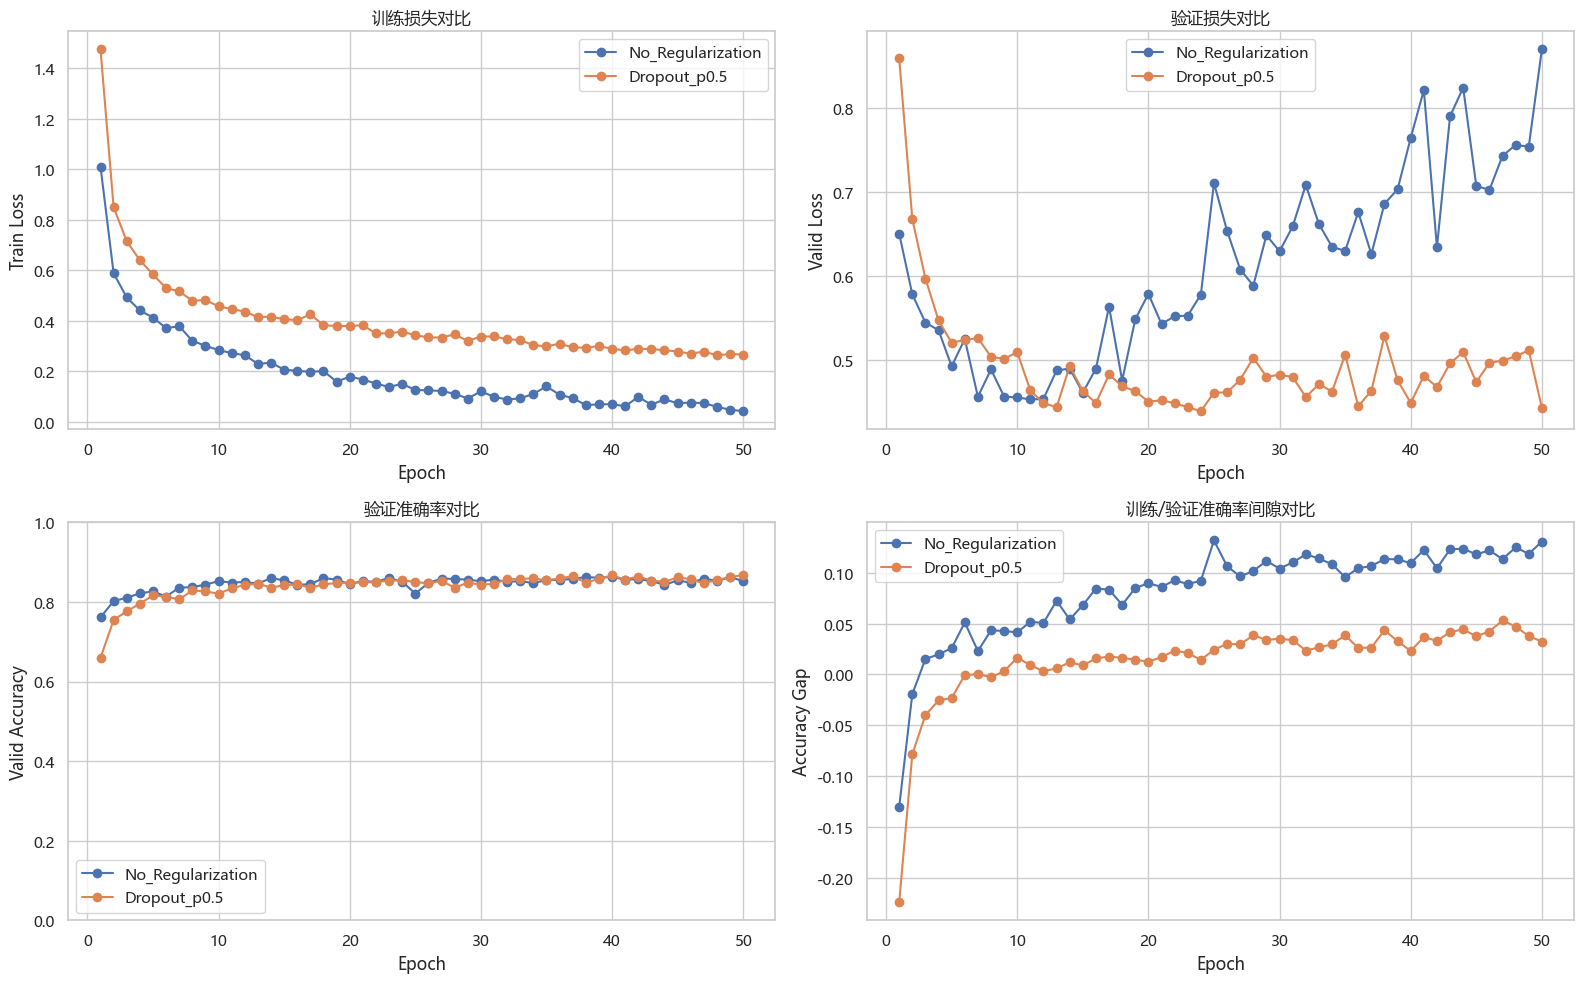

In [7]:
def plot_comparison(histories: dict[str, pd.DataFrame]) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for experiment_name, history_df in histories.items():
        axes[0, 0].plot(
            history_df["epoch"], history_df["train_loss"], marker="o", label=experiment_name
        )
        axes[0, 1].plot(
            history_df["epoch"], history_df["valid_loss"], marker="o", label=experiment_name
        )
        axes[1, 0].plot(
            history_df["epoch"], history_df["valid_accuracy"], marker="o", label=experiment_name
        )
        axes[1, 1].plot(
            history_df["epoch"], history_df["accuracy_gap"], marker="o", label=experiment_name
        )

    axes[0, 0].set_title("训练损失对比")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Train Loss")
    axes[0, 0].legend()

    axes[0, 1].set_title("验证损失对比")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Valid Loss")
    axes[0, 1].legend()

    axes[1, 0].set_title("验证准确率对比")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Valid Accuracy")
    axes[1, 0].set_ylim(0, 1.0)
    axes[1, 0].legend()

    axes[1, 1].set_title("训练/验证准确率间隙对比")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Accuracy Gap")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


plot_comparison(histories)


## 实验小结

等你把任务四跑完后，写结果分析时可以重点回答下面几个问题：

1. 不加正则化的深层网络，是否出现了明显的过拟合？
2. 过拟合大概从第几轮开始变明显？
3. 加入 Dropout 后，验证集准确率是否更稳定？
4. 加入 Dropout 后，训练/验证之间的 gap 是否减小？
5. 为什么“训练准确率稍微低一些”不一定是坏事？

这一题最核心的理解不是“谁训练得更猛”，
而是“谁更不容易只记住训练集”。

如果你看到：

- 无正则化模型训练准确率很高
- 但验证准确率后期下降，gap 越拉越大

那就是比较典型的过拟合现象。

如果你又看到：

- 加入 Dropout 后训练准确率没那么夸张
- 但验证准确率更稳，gap 更小

那就说明正则化起到了缓解过拟合的作用。
